# PR 2. Data Cleaner

#   Project Name :- Patient Helth Records
Objective - To clean and preprocess the patient health dataset by identifying and handling missing values and outliers using different statistical techniques, making the data suitable for machine learning and disease-risk prediction.

In [1]:
# ====== load Liabaries
import numpy as np
import pandas as pd

In [2]:
# ======= Load dataset
data = pd.read_csv("C://Users//Asus// Data Preprocessing and Feature Engineering//Data_Cleanser_Project_2//patient_health_records_50000.csv")
data

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,100001,53.0,Male,West,17.49,103.5,195.2,95.4,0
1,100002,31.0,Female,South,24.67,120.0,243.0,96.4,0
2,100003,60.0,Female,East,31.96,110.1,235.0,72.0,0
3,100004,63.0,Female,South,33.16,150.2,235.0,123.8,1
4,100005,18.0,Male,North,19.36,113.0,134.8,96.6,0
...,...,...,...,...,...,...,...,...,...
49995,149996,53.0,Female,North,28.80,118.0,170.9,96.1,0
49996,149997,77.0,Male,East,25.92,146.2,198.1,92.1,0
49997,149998,54.0,Female,North,20.99,108.5,171.9,90.6,0
49998,149999,70.0,Male,South,22.12,126.2,200.0,87.8,0


In [3]:
# ======= data information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      50000 non-null  int64  
 1   age             49807 non-null  float64
 2   gender          49900 non-null  str    
 3   region          49887 non-null  str    
 4   bmi             49784 non-null  float64
 5   blood_pressure  50000 non-null  float64
 6   cholesterol     49798 non-null  float64
 7   glucose         49815 non-null  float64
 8   disease_risk    50000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 3.9 MB


In [4]:
# ====== Missing values

missing_values = data.isnull().sum()
print(missing_values)

patient_id          0
age               193
gender            100
region            113
bmi               216
blood_pressure      0
cholesterol       202
glucose           185
disease_risk        0
dtype: int64


# Part A : Handle missing values

Q 1 :- Missing value summary report

In [5]:
missing_c = data.isnull().sum()
missing_p = (data.isnull().mean() * 100)

missing_report = pd.DataFrame({
    "Missing Count": missing_c,
    "Missing Percentage": missing_p
})

display(missing_report)

,Missing Count,Missing Percentage
patient_id,0,0.000
age,193,0.386
gender,100,0.200
region,113,0.226
bmi,216,0.432
blood_pressure,0,0.000
cholesterol,202,0.404
glucose,185,0.370
disease_risk,0,0.000


Question 2 :- Impution Techniques

# Q :- Simple_Imputation BMI mean & median (Numarical)
“First, I identified the missing BMI values. Then I used Simple Imputer with mean and median strategies to replace the missing values. Finally, I checked the missing-value count to verify that the BMI column was completely imputed

In [6]:
from sklearn.impute import SimpleImputer

#  Before Imputation

print("========== BEFORE IMPUTATION ==========")

print("\nMissing BMI values:")
print(data.loc[data["bmi"].isnull(), "bmi"])

print("\nTotal missing BMI:")
print(data["bmi"].isnull().sum())


#   Simple Imputer (Mean)

print("\n========== MEAN IMPUTATION ==========")

BMI_mean = SimpleImputer(strategy="mean")
data["bmi"] = BMI_mean.fit_transform(data[["bmi"]]).ravel()
print("\nBMI after Mean Imputation:")
print(data["bmi"])

print("\nMissing BMI after Mean:")
print(data["bmi"].isnull().sum())


#  Simple Imputer (Median)

print("\n========== MEDIAN IMPUTATION ==========")

BMI_median = SimpleImputer(strategy="median")
data["bmi"] = BMI_median.fit_transform(data[["bmi"]]).ravel()
print("\nBMI after Median Imputation:")
print(data["bmi"])

print("\nMissing BMI after Median:")
print(data["bmi"].isnull().sum())

========== BEFORE IMPUTATION ==========

Missing BMI values:
648     NaN
1123    NaN
1230    NaN
1249    NaN
1379    NaN
         ..
49486   NaN
49638   NaN
49899   NaN
49901   NaN
49929   NaN
Name: bmi, Length: 216, dtype: float64

Total missing BMI:
216

========== MEAN IMPUTATION ==========

BMI after Mean Imputation:
0        17.49
1        24.67
2        31.96
3        33.16
4        19.36
         ...  
49995    28.80
49996    25.92
49997    20.99
49998    22.12
49999    20.80
Name: bmi, Length: 50000, dtype: float64

Missing BMI after Mean:
0

========== MEDIAN IMPUTATION ==========

BMI after Median Imputation:
0        17.49
1        24.67
2        31.96
3        33.16
4        19.36
         ...  
49995    28.80
49996    25.92
49997    20.99
49998    22.12
49999    20.80
Name: bmi, Length: 50000, dtype: float64

Missing BMI after Median:
0


# Q :- Region SimpleImputer (Categorical)
Region is a categorical variable, so I used SimpleImputer with the most-frequent strategy. The missing region values were replaced with the region that occurred most frequently in the dataset.

In [7]:

print("Orignal Data")
data_simpleimputer = data.copy()
print(data_simpleimputer.loc[data_simpleimputer["region"].isnull(),"region"])

# ------ most frequent value ------

print("\n======== Most Frequent Imputation ======")
region_frequent = SimpleImputer(strategy = "most_frequent")
data_simpleimputer["region"] = region_frequent.fit_transform(data_simpleimputer[["region"]]).ravel()
print("after mode imputation :\n]")
data_simpleimputer["region"]

Orignal Data
556      NaN
1663     NaN
1985     NaN
2571     NaN
3689     NaN
        ... 
48198    NaN
48396    NaN
49135    NaN
49386    NaN
49554    NaN
Name: region, Length: 113, dtype: str

======== Most Frequent Imputation ======
after mode imputation :
]


0         West
1        South
2         East
3        South
4        North
         ...  
49995    North
49996     East
49997    North
49998    South
49999     East
Name: region, Length: 50000, dtype: str

# Q :- Most Frequent Imputation (Gender)
Gender is a categorical variable, so I used Most Frequent Imputation. The missing gender values were replaced with the most frequently occurring gender in the dataset.

In [8]:

print("Orignal Data \n")
data_frequent = data.copy()
print(data_frequent.loc[data_frequent["gender"].isnull(),"gender"])

print("\n====== most frequent imputation(gender) ======")
gender_imputer = SimpleImputer(strategy = "most_frequent")
data["gender"] = gender_imputer.fit_transform(data_frequent[["gender"]]).ravel()
data["gender"]


Orignal Data 

125      NaN
212      NaN
517      NaN
1654     NaN
1839     NaN
        ... 
44547    NaN
45378    NaN
47418    NaN
47677    NaN
48632    NaN
Name: gender, Length: 100, dtype: str

====== most frequent imputation(gender) ======


0          Male
1        Female
2        Female
3        Female
4          Male
          ...  
49995    Female
49996      Male
49997    Female
49998      Male
49999      Male
Name: gender, Length: 50000, dtype: str

# Q :- missing indicator + random sample imputation
First, I created a binary missing indicator to identify which records originally had missing values. Then, I randomly selected values from the available non-missing data and used them to fill the missing values

In [9]:
print("========== ORIGINAL DATA ==========")
print("Total Rows:", len(data))
print("\nMissing Values:")
print(data.isnull().sum())
data_mis = data.copy()

# === Missing Indicator

missing_columns = data_mis.columns[data_mis.isnull().any()]

for col in missing_columns:
    data[col + "_missing"] = data_mis[col].isnull().astype(int)


# === Random Sample Imputation

for col in missing_columns:
    missing_index = data_mis[data_mis[col].isnull()].index
    non_missing_values = data_mis[col].dropna()
    random_sample = non_missing_values.sample(n=len(missing_index),random_state=42,replace=True)

    random_sample.index = missing_index

    data_mis.loc[missing_index, col] = random_sample
    
# Result

print("\n========== AFTER IMPUTATION ==========")

print("\nMissing Values:")
print(data_mis[missing_columns].isnull().sum())

print("\nMissing Indicator Columns:")
print([
    col + "_missing"
    for col in missing_columns
])

print("\nSample Result:")
print(data_mis.head(10))

========== ORIGINAL DATA ==========
Total Rows: 50000

Missing Values:
patient_id          0
age               193
gender              0
region            113
bmi                 0
blood_pressure      0
cholesterol       202
glucose           185
disease_risk        0
dtype: int64

========== AFTER IMPUTATION ==========

Missing Values:
age            0
region         0
cholesterol    0
glucose        0
dtype: int64

Missing Indicator Columns:
['age_missing', 'region_missing', 'cholesterol_missing', 'glucose_missing']

Sample Result:
   patient_id   age  gender region    bmi  blood_pressure  cholesterol  \
0      100001  53.0    Male   West  17.49           103.5        195.2   
1      100002  31.0  Female  South  24.67           120.0        243.0   
2      100003  60.0  Female   East  31.96           110.1        235.0   
3      100004  63.0  Female  South  33.16           150.2        235.0   
4      100005  18.0    Male  North  19.36           113.0        134.8   
5      100006  2

# Q - KNN imputer
KNN Imputer was used to handle missing numerical values. It estimates each missing value using information from the five nearest similar records. Finally, we verified that the missing values were successfully imputed.

In [10]:
# Q - KNN imputer

from sklearn.impute import KNNImputer
data_knn = data.copy()

numeric_columns = ["age","bmi","blood_pressure","cholesterol","glucose"]

# Before
print("Missing values before:")
print(data_knn[numeric_columns].isnull().sum())

# KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)
data_knn[numeric_columns] = knn_imputer.fit_transform(data_knn[numeric_columns])

# After
print("\nMissing values after:")
print(data_knn[numeric_columns].isnull().sum())

Missing values before:
age               193
bmi                 0
blood_pressure      0
cholesterol       202
glucose           185
dtype: int64

Missing values after:
age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64


# Q :- MICE Algorithm
MICE stands for Multiple Imputation by Chained Equations. It handles missing values by using relationships between different variables and repeatedly estimating the missing values. This provides a more reliable imputation than simple mean or median replacement

In [11]:

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

data_mice = data.copy()

numeric_columns = ["age","bmi","blood_pressure","cholesterol","glucose"]

mice_imputer = IterativeImputer(max_iter=10,random_state=42)

data_mice[numeric_columns] = mice_imputer.fit_transform(data_mice[numeric_columns])

print(data_mice[numeric_columns].isnull().sum())

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64


#  Part B :- Handling Outlier

Q 3 :-Detect and Remove Outlier

# Q3(a) :- Z-Score Method :Identify patients with extreme cholesterol or glucose values
I used the Z-score method to identify extreme cholesterol and glucose values. Values with an absolute Z-score greater than 3 were considered outliers and removed from the dataset.

In [12]:

from scipy.stats import zscore

data_z = data.copy()

# Step 1: Temporarily fill missing values
data_z["cholesterol_temp"] = data_z["cholesterol"].fillna(
    data_z["cholesterol"].mean()
)

data_z["glucose_temp"] = data_z["glucose"].fillna(
    data_z["glucose"].mean()
)

# Step 2: Calculate Z-Score
data_z["cholesterol_z"] = zscore(
    data_z["cholesterol_temp"]
)

data_z["glucose_z"] = zscore(
    data_z["glucose_temp"]
)

# Step 3: Identify outliers
z_outliers = data_z[
    (data_z["cholesterol_z"].abs() > 3) |
    (data_z["glucose_z"].abs() > 3)
]

print("Total Z-Score Outliers:", len(z_outliers))

# Step 4: Remove outliers
data_z_clean = data_z[
    (data_z["cholesterol_z"].abs() <= 3) &
    (data_z["glucose_z"].abs() <= 3)
].copy()

# Step 5: Remove temporary columns
data_z_clean.drop(
    columns=[
        "cholesterol_temp",
        "glucose_temp",
        "cholesterol_z",
        "glucose_z"
    ],
    inplace=True
)

# Step 6: Compare shape
print("\nOriginal Shape:", data.shape)
print("After Z-Score:", data_z_clean.shape)

Total Z-Score Outliers: 319

Original Shape: (50000, 13)
After Z-Score: (49681, 13)


# Q :- IQR Method
I used the IQR method to detect unusual BMI values. I calculated Q1, Q3 and IQR, then identified values outside the lower and upper fences as outliers and removed them from the dataset

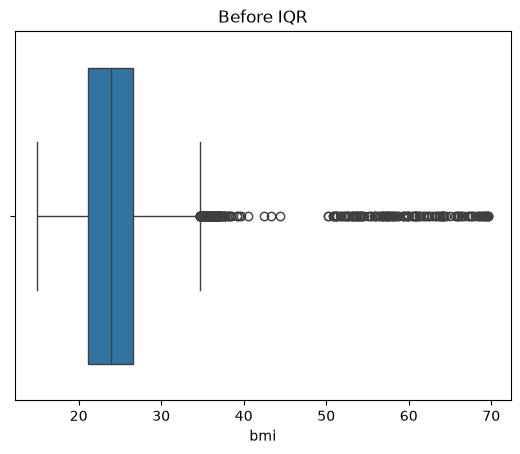

Total BMI Outliers: 322


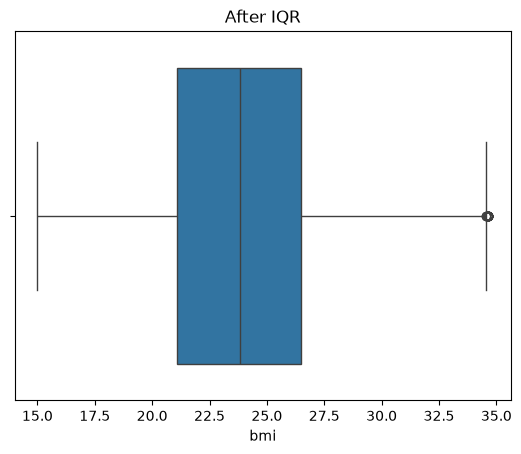

In [13]:
# Q :- IQR Method

import seaborn as sns
import matplotlib.pyplot as plt

data_iqr = data.copy()

# Before
sns.boxplot(x=data_iqr["bmi"])
plt.title("Before IQR")
plt.show()

# IQR
Q1 = data_iqr["bmi"].quantile(0.25)
Q3 = data_iqr["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Outliers
outliers = data_iqr[
    (data_iqr["bmi"] < lower_fence) |
    (data_iqr["bmi"] > upper_fence)
]

print("Total BMI Outliers:", len(outliers))

# Delete outliers
data_clean = data_iqr[
    (data_iqr["bmi"] >= lower_fence) &
    (data_iqr["bmi"] <= upper_fence)
].copy()

# After
sns.boxplot(x=data_clean["bmi"])
plt.title("After IQR")
plt.show()

# Q :- Percentile Method : Cap values below 1st percentile and above 99th percentile
“I used the percentile method to control extreme values. Values below the 1st percentile were capped at the 1st percentile, and values above the 99th percentile were capped at the 99th percentile. This reduced the effect of extreme values without removing patient records

Before: (50000, 13)
After : (50000, 13)


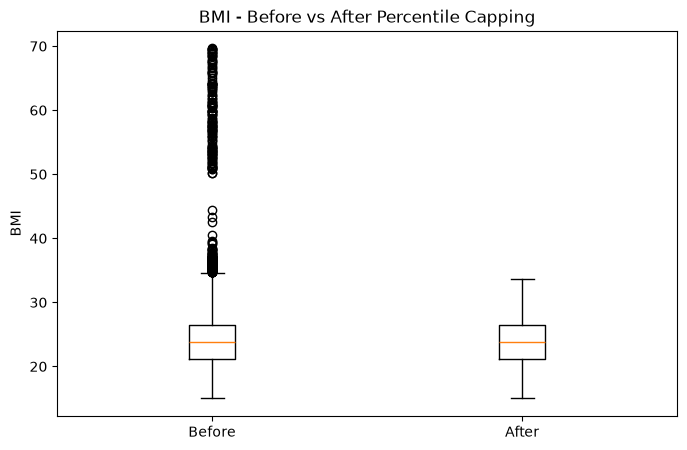

In [14]:


# Q3(c) :- Percentile Method

data_percentile = data.copy()

numeric_columns = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

for col in numeric_columns:

    lower = data_percentile[col].quantile(0.01)
    upper = data_percentile[col].quantile(0.99)

    data_percentile[col] = data_percentile[col].clip(
        lower=lower,
        upper=upper
    )

print("Before:", data.shape)
print("After :", data_percentile.shape)



plt.figure(figsize=(8, 5))

plt.boxplot([
    data["bmi"].dropna(),
    data_percentile["bmi"].dropna()
])

plt.xticks([1, 2], ["Before", "After"])
plt.title("BMI - Before vs After Percentile Capping")
plt.ylabel("BMI")

plt.show()

# Q 4 :- Winsorization : Cap extreme outliers instead of removing them
“I used Winsorization to handle extreme outliers without removing patient records. Extreme low and high values were capped at predefined limits, which reduced the effect of outliers while preserving the original dataset size.

Lower Limit: 15.0
Upper Limit: 33.65


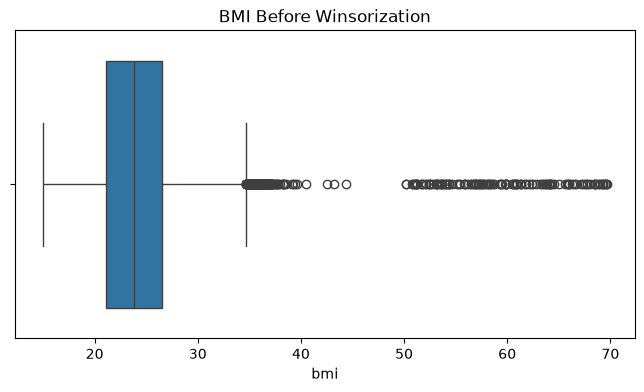

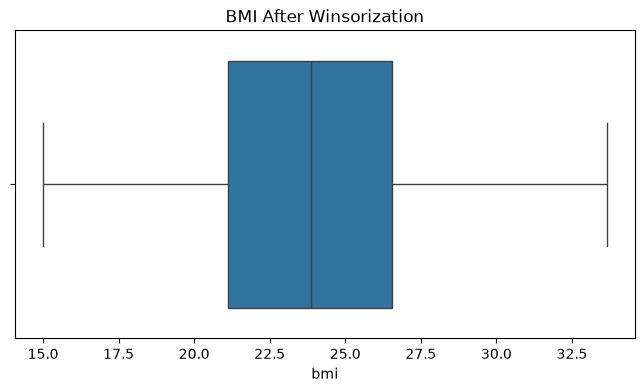

In [15]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_winsor = data.copy()

# Lower and Upper limits
lower = data_winsor["bmi"].quantile(0.01)
upper = data_winsor["bmi"].quantile(0.99)

print("Lower Limit:", lower)
print("Upper Limit:", upper)

# Before
plt.figure(figsize=(8, 4))
sns.boxplot(x=data_winsor["bmi"])
plt.title("BMI Before Winsorization")
plt.show()

# Winsorization / Capping
data_winsor["bmi"] = np.clip(
    data_winsor["bmi"],
    lower,
    upper
)

# After
plt.figure(figsize=(8, 4))
sns.boxplot(x=data_winsor["bmi"])
plt.title("BMI After Winsorization")
plt.show()

# Q5 :- before VS after outlier treatment
I compared the dataset before and after outlier treatment using dataset shape and summary statistics. This comparison helped evaluate how outlier handling affected the data distribution and overall data quality

In [16]:
# Q5 :- Shape Comparison

print("========== SHAPE COMPARISON ==========")

print("Original Data      :", data.shape)
print("After Z-Score      :", data_z_clean.shape)
print("After IQR          :", data_clean.shape)
print("After Percentile   :", data_percentile.shape)
print("After Winsorization:", data_winsor.shape)

========== SHAPE COMPARISON ==========
Original Data      : (50000, 13)
After Z-Score      : (49681, 13)
After IQR          : (49678, 13)
After Percentile   : (50000, 13)
After Winsorization: (50000, 13)


In [17]:
print("\n========== ORIGINAL DATA ==========")

print(
    data[
        ["age", "bmi", "blood_pressure",
         "cholesterol", "glucose"]
    ].describe()
)

print("\n========== AFTER WINSORIZATION ==========")

print(
    data_winsor[
        ["age", "bmi", "blood_pressure",
         "cholesterol", "glucose"]
    ].describe()
)


========== ORIGINAL DATA ==========
                age           bmi  blood_pressure   cholesterol       glucose
count  49807.000000  50000.000000    50000.000000  49798.000000  49815.000000
mean      48.154175     23.928499      120.600678    188.173854     91.592970
std       15.542703      4.382958       14.030658     32.195788     19.612176
min       18.000000     15.000000       80.000000    100.000000     60.000000
25%       37.000000     21.110000      111.900000    167.400000     80.800000
50%       48.000000     23.860000      120.200000    187.500000     90.800000
75%       59.000000     26.530000      128.500000    207.600000    101.000000
max       90.000000     69.640000      259.400000    499.100000    399.900000

========== AFTER WINSORIZATION ==========
                age           bmi  blood_pressure   cholesterol       glucose
count  49807.000000  50000.000000    50000.000000  49798.000000  49815.000000
mean      48.154175     23.848958      120.600678    188.17385

#  Part C :- Final clean dataset 

In [18]:
# Q6 :- Final Clean Dataset

data_final = data_winsor.copy()

print("========== FINAL CLEAN DATASET ==========")
print("Shape:", data_final.shape)
print("\nMissing Values:")
print(data_final.isnull().sum())

print("\nDuplicate Rows:")
print(data_final.duplicated().sum())

print("\nFirst 5 Records:")
print(data_final.head())

========== FINAL CLEAN DATASET ==========
Shape: (50000, 13)

Missing Values:
patient_id               0
age                    193
gender                   0
region                 113
bmi                      0
blood_pressure           0
cholesterol            202
glucose                185
disease_risk             0
age_missing              0
region_missing           0
cholesterol_missing      0
glucose_missing          0
dtype: int64

Duplicate Rows:
0

First 5 Records:
   patient_id   age  gender region    bmi  blood_pressure  cholesterol  \
0      100001  53.0    Male   West  17.49           103.5        195.2   
1      100002  31.0  Female  South  24.67           120.0        243.0   
2      100003  60.0  Female   East  31.96           110.1        235.0   
3      100004  63.0  Female  South  33.16           150.2        235.0   
4      100005  18.0    Male  North  19.36           113.0        134.8   

   glucose  disease_risk  age_missing  region_missing  cholesterol_missing  

In [19]:
data_final.to_csv(
    "patient_health_records_final_clean.csv",
    index=False
)

print("Final clean dataset saved successfully!")

Final clean dataset saved successfully!
